
# Driver Monitoring System (DMS) — Phone Detection Module
### YOLOv8m | Ultralytics | Google Colab



This notebook trains, evaluates, and deploys a YOLOv8m object detector that identifies
whether a driver is **holding / using a mobile phone** while driving. It is one module
of a larger **Driver Monitoring System (DMS)**
---


# 1. Project Introduction

## Overview
This notebook presents the complete workflow for training a deep learning model to detect mobile phone usage by drivers. The model is developed using the YOLOv8 object detection framework and is intended to be integrated into a Driver Monitoring System (DMS) for real-time driver behavior analysis.

## Driver Monitoring System (DMS)
A Driver Monitoring System is designed to observe the driver's behavior during vehicle operation and identify actions that may affect road safety. These systems use computer vision techniques to monitor the driver and generate alerts when unsafe behavior is detected. Common monitoring tasks include driver distraction, drowsiness, seatbelt compliance, and mobile phone usage.

## Importance of Phone Usage Detection
Using a mobile phone while driving reduces the driver's attention and increases the risk of traffic accidents. An automatic detection model can identify this behavior in real time, allowing the system to issue warnings or record safety events for further analysis.

## Notebook Objectives
The main objectives of this notebook are to:

- Prepare and validate the training dataset.
- Train a YOLOv8 model using transfer learning.
- Evaluate the trained model using standard object detection metrics.
- Test the model on unseen images and videos.
- Export the final model for deployment in the Driver Monitoring System.

## Workflow
The notebook follows the training pipeline in the following order:

1. Environment setup
2. Dataset preparation
3. Dataset validation
4. Model training
5. Model evaluation
6. Inference on test data
7. Model export

## 2. Environment Setup

The first step is to install the required Python libraries used throughout this notebook. These packages provide the tools needed for dataset processing, model training, visualization, and performance evaluation. Installing them at the beginning ensures that all subsequent sections run without dependency issues.

In [1]:

# Install required packages
!pip install -q ultralytics==8.3.* opencv-python supervision matplotlib seaborn pandas numpy scikit-learn tqdm

print(" All required libraries installed successfully.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 5.6 MB/s eta 0:00:00
 All required libraries installed successfully.


## 3. Import Libraries

This section imports all the libraries required for the project. The imported packages are used for data handling, image processing, visualization, model training, evaluation, and file management. Random seeds are also initialized to improve the reproducibility of the training process.

In [2]:


# Standard library

import os
import sys
import glob
import shutil
import random
import time
import json
import warnings
from pathlib import Path
from datetime import datetime


# Data science / numerical

import numpy as np
import pandas as pd


# Visualization

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns


# Computer vision

import cv2
from PIL import Image
import supervision as sv


# Deep learning / YOLOv8

import torch
from ultralytics import YOLO


# Utilities

from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f" Libraries imported successfully.")
print(f" PyTorch version : {torch.__version__}")
print(f"  CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU device      : {torch.cuda.get_device_name(0)}")
else:
    print(" No GPU detected. Go to Runtime > Change runtime type > GPU for faster training.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Libraries imported successfully.
 PyTorch version : 2.11.0+cu128
  CUDA available  : True
 GPU device      : Tesla T4


## 4. Connect Google Drive

Google Drive is mounted to access the dataset and to save all generated files during the training process. This includes trained models, prediction results, evaluation plots, and other outputs, making it easier to keep the project files organized and available after the Colab session ends.

### Recommended Project Structure

```
MyDrive/
└── DMS_Phone_Detection/
    ├── dataset/
    │   ├── train/
    │   │   ├── images/
    │   │   └── labels/
    │   ├── valid/
    │   │   ├── images/
    │   │   └── labels/
    │   ├── test/          (optional)
    │   └── data.yaml
    ├── runs/
    ├── models/
    ├── outputs/
    └── reports/
```

This folder organization helps keep the dataset, trained models, evaluation results, and exported files separated and easy to manage throughout the project.

In [ ]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

ZIP_PATH = Path("/content/drive/MyDrive/ final mobile Phone.yolov8.zip")

BASE_DIR = Path("/content/dataset")
LOCAL_ZIP = Path("/content/dataset.zip")

os.makedirs(BASE_DIR, exist_ok=True)

print("Drive mounted")
print("ZIP path:", ZIP_PATH)
print("Extract folder:", BASE_DIR)

Mounted at /content/drive
Drive mounted
ZIP path: /content/drive/MyDrive/ final mobile Phone.yolov8.zip
Extract folder: /content/dataset


In [ ]:
import shutil
import zipfile

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP not found: {ZIP_PATH}")

shutil.copy(ZIP_PATH, LOCAL_ZIP)

with zipfile.ZipFile(LOCAL_ZIP, "r") as zip_ref:
    zip_ref.extractall(BASE_DIR)

print("Dataset extracted successfully")

Dataset extracted successfully


In [ ]:
import os

for root, dirs, files in os.walk(BASE_DIR):
    print(root)
    if files:
        print("Files:", files[:5])

/content/dataset
Files: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml']
/content/dataset/valid
/content/dataset/valid/labels
Files: ['1001-322-_jpg.rf.TqwRSROcmGB0lPWW3ntf.txt', 'im_phone_152_jpg.rf.N7kZJ0St25GS4PHriuYN.txt', '1001-53-_jpg.rf.jALIfBbTr9ftodsCYmu9.txt', '1001-506-_jpg.rf.3955lEvaCf66szL0Ez1p.txt', 'IMG20211009235904_jpg.rf.n8eJqozclLxR52cmGTPJ.txt']
/content/dataset/valid/images
Files: ['1001-213-_jpg.rf.KKhHekl0xUUDrl1sfaHF.jpg', 'pp219_jpg.rf.3IgB5gvt0LHud1w6t3Bq.jpg', '1001-96-_jpg.rf.kYnhQVVvTp85u9YcJvBE.jpg', '1001-681-_jpg.rf.CwhgdNlHviocnuFEgVjc.jpg', '_-2-_mp4-27_jpg.rf.jsOllx0kDYeXjKPl3aZm.jpg']
/content/dataset/train
/content/dataset/train/labels
Files: ['e5e67a59-17cb-45e3-a659-1e601dc48ad3-stocksy_txp361b7027fz7200_small_2072020_jpg.rf.8VHCFXVT7fNUowPo3XrF.txt', 'xyzzzzzz (90)_jpg.rf.S6EzTmrpXdOpV0clJqqZ.txt', '012291302267_221215101003-02_jpeg_jpg.rf.FpHo20v5e73cnDVpP0F6.txt', 'WIN_20220722_12_32_18_Pro_jpg.rf.rZzckA8ne9POAPAvIiAD.txt', 'f19e4312

In [ ]:
from pathlib import Path

DATASET_ROOT = Path("/content/dataset")

print("Dataset root:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Dataset root: /content/dataset
Exists: True



## 5. Dataset Preparation


Before training the model, the dataset is inspected to verify that it is correctly organized and ready for training. This step loads the dataset configuration, checks the available classes, summarizes the number of images and annotation files in each split, and displays a few annotated samples for visual inspection.

Performing these checks helps identify common issues, such as missing labels or incorrect annotations, before starting the training process.



This cell loads the dataset configuration file (`data.yaml`) and retrieves the class names that will be used during training and evaluation.

In [ ]:
import yaml

DATA_YAML_PATH = DATASET_ROOT / "data.yaml"

with open(DATA_YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

print("Classes:", data_cfg.get("names"))
print("YAML loaded successfully")

Classes: ['cell phone']
YAML loaded successfully




This step counts the number of images and annotation files in each dataset split to verify that the dataset has been prepared correctly before training.

In [ ]:
from pathlib import Path

def count_split(images_path):
    """Count images and labels in one dataset split."""

    image_extensions = [".jpg", ".jpeg", ".png"]

    image_count = sum(
        1 for file in images_path.iterdir()
        if file.suffix.lower() in image_extensions
    )

    labels_path = images_path.parent / "labels"

    label_count = 0
    if labels_path.exists():
        label_count = len(list(labels_path.glob("*.txt")))

    return image_count, label_count


splits = {
    "train": Path("/content/dataset/train/images"),
    "valid": Path("/content/dataset/valid/images"),
}

total_images = 0

print("Dataset Summary")
print("=" * 40)

for split_name, images_path in splits.items():

    if not images_path.exists():
        print(f"{split_name} folder not found")
        continue

    num_images, num_labels = count_split(images_path)

    print(f"{split_name:<6} | images: {num_images} | labels: {num_labels}")

    total_images += num_images

print("=" * 40)
print(f"Total images: {total_images}")

Dataset Summary
train  | images: 1165 | labels: 1165
valid  | images: 350 | labels: 350
Total images: 1515



## 6.Dataset Visualization

This cell verifies that the images and YOLO annotation files are correctly matched. It also includes helper functions to read label files, convert YOLO bounding box coordinates into image coordinates, and visualize annotated samples from the dataset.

This step helps ensure that the dataset annotations are correct before starting the model training process.

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def yolo_to_xyxy(box, img_w, img_h):
    x_c, y_c, w, h = box
    x1 = (x_c - w / 2) * img_w
    y1 = (y_c - h / 2) * img_h
    x2 = (x_c + w / 2) * img_w
    y2 = (y_c + h / 2) * img_h
    return x1, y1, x2, y2


def load_labels(label_path):
    boxes = []

    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id, x, y, w, h = parts
                boxes.append((int(cls_id), float(x), float(y), float(w), float(h)))

    return boxes


def show_samples(images_dir, labels_dir, class_names, num_samples=8):
    image_files = [
        f for f in os.listdir(images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    samples = random.sample(image_files, min(num_samples, len(image_files)))

    plt.figure(figsize=(15, 10))

    for i, img_name in enumerate(samples):
        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, img_name.replace(".jpg", ".txt").replace(".png", ".txt"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        plt.subplot(2, 4, i + 1)
        plt.imshow(image)

        for cls_id, x, y, bw, bh in load_labels(label_path):
            x1, y1, x2, y2 = yolo_to_xyxy((x, y, bw, bh), w, h)

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            plt.gca().add_patch(rect)

            label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
            plt.text(x1, y1 - 5, label, color="white",
                     bbox=dict(facecolor="red", alpha=0.7))

        plt.axis("off")

    plt.tight_layout()
    plt.show()



This step checks the consistency of the training dataset by matching images with their annotation files. It also displays random samples with bounding boxes to confirm that the labels are correctly placed before model training.

In [ ]:
from pathlib import Path

images = {Path(f).stem for f in os.listdir("/content/dataset/train/images")}
labels = {Path(f).stem for f in os.listdir("/content/dataset/train/labels")}

print("Images:", len(images))
print("Labels:", len(labels))
print("Matched:", len(images & labels))
print("Missing labels:", len(images - labels))

Images: 1165
Labels: 1165
Matched: 1165
Missing labels: 0


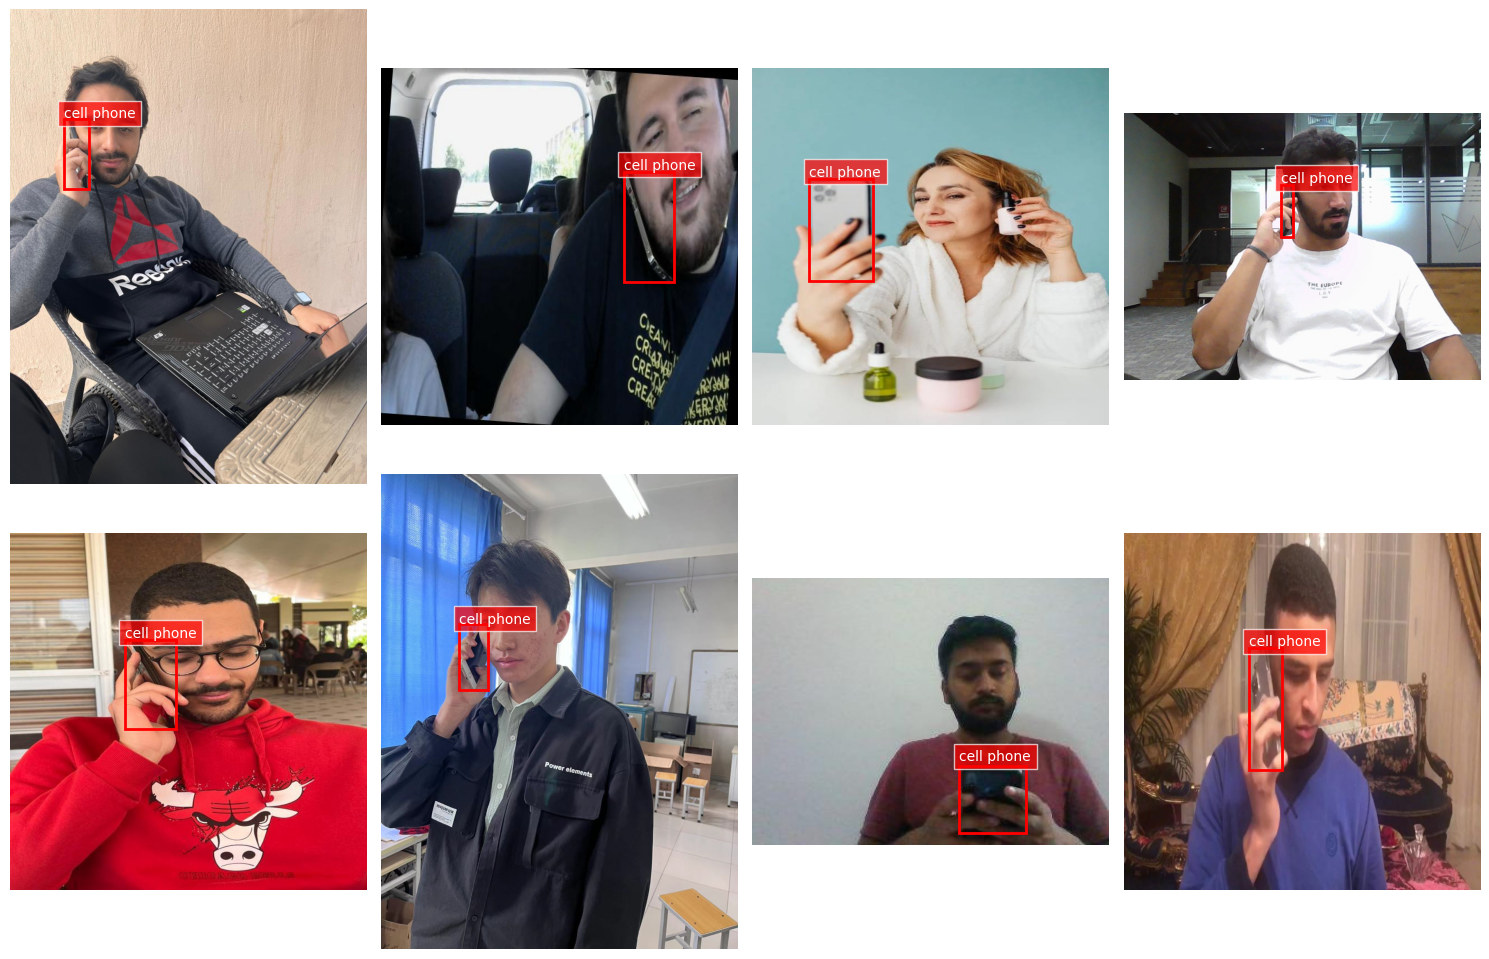

In [ ]:
images_dir = "/content/dataset/train/images"
labels_dir = "/content/dataset/train/labels"

class_names = data_cfg["names"]

show_samples(images_dir, labels_dir, class_names)


## 7. Data Quality Checking

Automated data-quality checks catch problems that are easy to miss manually:

- **Missing labels** — an image with no corresponding `.txt` label file.
- **Corrupted images** — files that cannot be opened/decoded.
- **Empty annotations** — a label file that exists but contains zero boxes.
- **Wrong class IDs** — a class id outside the valid range `[0, NUM_CLASSES-1]`.


In [ ]:
import cv2
from pathlib import Path

DATASET_PATH = Path("/content/dataset")

IMAGE_EXTS = [".jpg", ".jpeg", ".png"]
splits = ["train", "valid"]

NUM_CLASSES = len(data_cfg["names"])

print("Number of classes:", NUM_CLASSES)
print("=" * 50)


def is_image_corrupted(img_path):
    try:
        img = cv2.imread(str(img_path))
        return img is None
    except:
        return True


def parse_label_file(label_path):
    if not label_path.exists():
        return None, "missing"

    try:
        with open(label_path, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            return [], "empty"

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                return None, "malformed"

            class_id = int(parts[0])

            if class_id < 0 or class_id >= NUM_CLASSES:
                return None, "wrong_class_id"

        return lines, "ok"

    except:
        return None, "corrupted"


issues = {
    "missing_labels": [],
    "corrupted_images": [],
    "empty_labels": [],
    "wrong_class_ids": []
}

total_images = 0

for split in splits:
    img_dir = DATASET_PATH / split / "images"
    label_dir = DATASET_PATH / split / "labels"

    print("Checking split:", split)

    for img_path in img_dir.rglob("*"):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue

        total_images += 1

        label_path = label_dir / (img_path.stem + ".txt")

        if is_image_corrupted(img_path):
            issues["corrupted_images"].append(str(img_path))
            continue

        label_data, status = parse_label_file(label_path)

        if status == "missing":
            issues["missing_labels"].append(str(img_path))

        elif status == "empty":
            issues["empty_labels"].append(str(img_path))

        elif status == "wrong_class_id":
            issues["wrong_class_ids"].append(str(img_path))


print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

print("Total images checked:", total_images)
print("Missing labels:", len(issues["missing_labels"]))
print("Corrupted images:", len(issues["corrupted_images"]))
print("Empty annotations:", len(issues["empty_labels"]))
print("Wrong class IDs:", len(issues["wrong_class_ids"]))
print("=" * 50)


def show_samples(title, items, max_show=5):
    print(title)
    for i, item in enumerate(items[:max_show]):
        print(i + 1, item)


if issues["missing_labels"]:
    show_samples("Missing Labels Samples", issues["missing_labels"])

if issues["corrupted_images"]:
    show_samples("Corrupted Images Samples", issues["corrupted_images"])

if issues["empty_labels"]:
    show_samples("Empty Labels Samples", issues["empty_labels"])

if issues["wrong_class_ids"]:
    show_samples("Wrong Class ID Samples", issues["wrong_class_ids"])

Number of classes: 1
Checking split: train
Checking split: valid
DATA QUALITY REPORT
Total images checked: 1515
Missing labels: 0
Corrupted images: 0
Empty annotations: 0
Wrong class IDs: 0



## 8. Data Augmentation

YOLOv8 applies **online augmentation** automatically during training (configured via
the `hyp`/training arguments, not a separate preprocessing step). The main
augmentations used are:

| Augmentation | Purpose |
|---|---|
| **Mosaic** | Combines 4 training images into one, improving small-object detection and context diversity. |
| **HSV shift** (`hsv_h`, `hsv_s`, `hsv_v`) | Randomly perturbs hue/saturation/value to simulate lighting/color changes (day, night, cabin lighting). |
| **Random flip** (`fliplr`) | Horizontal flip to augment viewpoint diversity. |
| **Translation & Scale** (`translate`, `scale`) | Randomly shifts/zooms objects to improve robustness to position and distance. |
| **Mixup / Copy-Paste** (optional) | Blends images or pastes objects across images to increase diversity of hard examples. |

Mosaic is automatically **disabled for the final epochs** (`close_mosaic`) so the model
fine-tunes on realistic, non-mosaiced images before finishing training.

Below we visualize a few examples of what YOLOv8's augmentation pipeline produces.


In [ ]:
import os
import cv2
import shutil
import random
import albumentations as A
from tqdm import tqdm

# =========================
# 1. Paths (عدليها لو مختلفة)
# =========================
IMG_DIR = "/content/dataset/train/images"
LBL_DIR = "/content/dataset/train/labels"

OUT_IMG_DIR = "/content/dataset_aug/train/images"
OUT_LBL_DIR = "/content/dataset_aug/train/labels"

os.makedirs(OUT_IMG_DIR, exist_ok=True)
os.makedirs(OUT_LBL_DIR, exist_ok=True)

# =========================
# 2. Augmentation Pipeline
# =========================
train_aug = A.Compose([
    A.MotionBlur(blur_limit=7, p=0.3),
    A.GaussNoise(p=0.3),

    A.RandomBrightnessContrast(p=0.5),
    A.RandomGamma(p=0.3),

    A.HueSaturationValue(p=0.3),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.4
    ),

    A.CoarseDropout(
        max_holes=8,
        max_height=32,
        max_width=32,
        p=0.3
    ),

    A.HorizontalFlip(p=0.5),

    A.Resize(640, 640)
],
bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels']
))

# =========================
# 3. Helper: Load YOLO labels
# =========================
def load_yolo_labels(label_path):
    bboxes = []
    class_labels = []

    if not os.path.exists(label_path):
        return bboxes, class_labels

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            cls, x, y, w, h = parts
            class_labels.append(int(cls))
            bboxes.append([float(x), float(y), float(w), float(h)])

    return bboxes, class_labels


# =========================
# 4. Helper: Save YOLO labels
# =========================
def save_yolo_labels(path, bboxes, class_labels):
    with open(path, "w") as f:
        for cls, box in zip(class_labels, bboxes):
            x, y, w, h = box
            f.write(f"{cls} {x} {y} {w} {h}\n")


# =========================
# 5. Augmentation Loop
# =========================
images = os.listdir(IMG_DIR)

AUG_PER_IMAGE = 2

for img_name in tqdm(images):

    img_path = os.path.join(IMG_DIR, img_name)
    label_path = os.path.join(LBL_DIR, img_name.replace(".jpg", ".txt"))

    image = cv2.imread(img_path)
    if image is None:
        continue

    bboxes, class_labels = load_yolo_labels(label_path)

    # =========================
    # Save original (copy)
    # =========================
    shutil.copy(img_path, os.path.join(OUT_IMG_DIR, img_name))
    if os.path.exists(label_path):
        shutil.copy(label_path, os.path.join(OUT_LBL_DIR, os.path.basename(label_path)))

    # =========================
    # Generate augmented images
    # =========================
    for i in range(AUG_PER_IMAGE):

        augmented = train_aug(
            image=image,
            bboxes=bboxes,
            class_labels=class_labels
        )

        aug_img = augmented["image"]
        aug_bboxes = augmented["bboxes"]
        aug_labels = augmented["class_labels"]

        new_name = img_name.replace(".jpg", f"_aug{i}.jpg")

        # save image
        cv2.imwrite(os.path.join(OUT_IMG_DIR, new_name), aug_img)

        # save labels
        save_yolo_labels(
            os.path.join(OUT_LBL_DIR, new_name.replace(".jpg", ".txt")),
            aug_bboxes,
            aug_labels
        )

print("Augmentation Done! Dataset saved at:", OUT_IMG_DIR)

100%|██████████| 1165/1165 [02:22<00:00,  8.19it/s]

✅ Augmentation Done! Dataset saved at: /content/dataset_aug/train/images


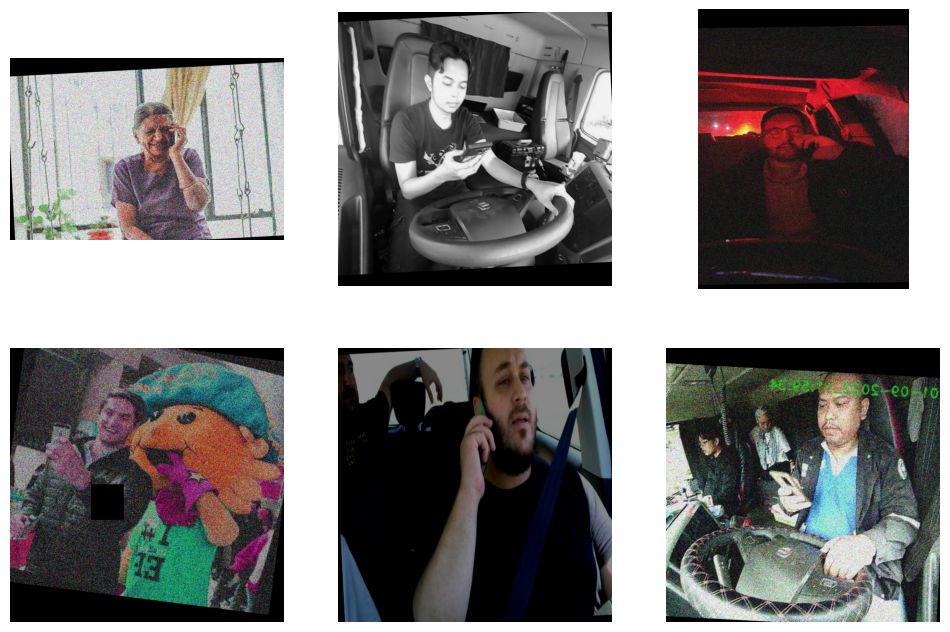

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
import os
import albumentations as A

image_dir = "/content/dataset/train/images"

train_aug = A.Compose([
    A.MotionBlur(p=0.5),
    A.GaussNoise(p=0.5),
    A.RandomBrightnessContrast(p=0.7),
    A.HueSaturationValue(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.7),
    A.CoarseDropout(p=0.4),
    A.HorizontalFlip(p=0.5),
])

images = os.listdir(image_dir)

plt.figure(figsize=(12,8))

for i in range(6):
    img_name = random.choice(images)
    img_path = os.path.join(image_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    augmented = train_aug(image=img)['image']

    plt.subplot(2,3,i+1)
    plt.imshow(augmented)
    plt.axis("off")

plt.show()


## 9. Load YOLOv8m Model


This cell loads the pretrained YOLOv8 medium model that will be used as the starting point for training. Transfer learning is applied by using pretrained weights, which helps the model achieve better performance and faster convergence compared to training from scratch.


In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 medium model
model = YOLO("yolov8m.pt")

print("Model loaded successfully")
print("Model type:", model.model.yaml.get("backbone", "YOLOv8m backbone loaded"))

Model loaded successfully
Model type: [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 3, 'C2f', [128, True]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 6, 'C2f', [256, True]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 6, 'C2f', [512, True]], [-1, 1, 'Conv', [768, 3, 2]], [-1, 3, 'C2f', [768, True]], [-1, 1, 'SPPF', [768, 5]]]



## 11. Train Model

This section trains the YOLOv8 model using the prepared dataset. The training process uses transfer learning with pretrained weights and applies different augmentation techniques to improve the model's ability to detect phone usage in different driving scenarios.

The training configuration includes the number of epochs, image size, optimizer settings, learning rate, and augmentation parameters. After training is completed, the generated model weights and training results are saved for further evaluation and testing.


In [ ]:
import time
from pathlib import Path
from ultralytics import YOLO


#  Paths

RUNS_DIR = Path("/content/drive/MyDrive/DMS_Phone_Detection/runs")
DATA_YAML_PATH = "/content/dataset/data.yaml"   # عدلي لو dataset_aug

SEED = 42


# 2. Load Model

model = YOLO("yolov8m.pt")


# 3. Train Config

TRAIN_CONFIG = dict(
    data=DATA_YAML_PATH,

    epochs=80,
    imgsz=640,

    batch=16,

    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,

    patience=25,

    weight_decay=0.0005,

    cache=False,
    workers=4,

    seed=SEED,

    #
    hsv_h=0.02,
    hsv_s=0.6,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,

    mosaic=1.0,
    mixup=0.1,
    close_mosaic=10,

    project=str(RUNS_DIR),
    name="dms_phone_yolov8m_v2",
    exist_ok=True,

    pretrained=True,
    verbose=True,
    plots=True
)


# 4. Train

train_start_time = time.time()

results = model.train(**TRAIN_CONFIG)

train_duration_sec = time.time() - train_start_time
train_duration_min = train_duration_sec / 60

print(
    f"\n✅ Training complete in {train_duration_min:.2f} minutes "
    f"({train_duration_sec/3600:.2f} hours)."
)

New https://pypi.org/project/ultralytics/8.4.84 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.253 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.6, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=dms_phone_yolov8m_v2, nbs=64, nms=False, 

In [ ]:


RUN_DIR = str(model.trainer.save_dir)
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
BEST_WEIGHTS_PATH = os.path.join(WEIGHTS_DIR, "best.pt")
LAST_WEIGHTS_PATH = os.path.join(WEIGHTS_DIR, "last.pt")

print(f"Run directory : {RUN_DIR}")
print(f"best.pt       : {BEST_WEIGHTS_PATH}  (exists: {os.path.exists(BEST_WEIGHTS_PATH)})")
print(f"last.pt       : {LAST_WEIGHTS_PATH}  (exists: {os.path.exists(LAST_WEIGHTS_PATH)})")


📁 Run directory : /content/drive/MyDrive/DMS_Phone_Detection/runs/dms_phone_yolov8m_v2
🏆 best.pt       : /content/drive/MyDrive/DMS_Phone_Detection/runs/dms_phone_yolov8m_v2/weights/best.pt  (exists: True)
🕗 last.pt       : /content/drive/MyDrive/DMS_Phone_Detection/runs/dms_phone_yolov8m_v2/weights/last.pt  (exists: True)



## 12. Save Best Model to Google Drive

Since `RUNS_DIR` already lives on Google Drive (via the mount), Ultralytics has
technically already saved the checkpoints there. For clarity and easy access, we
additionally copy `best.pt` and `last.pt` into a dedicated, timestamped folder under
`models/` — this makes it trivial to find "the" production model without digging
through run folders.


In [ ]:
import shutil
import os
from datetime import datetime

MODELS_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODELS_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

save_dir = os.path.join(MODELS_DIR, f"phone_detector_{timestamp}")
os.makedirs(save_dir, exist_ok=True)

shutil.copy2(
    "/content/drive/MyDrive/DMS_Phone_Detection/runs/dms_phone_yolov8m_v2/weights/best.pt",
    os.path.join(save_dir, "best.pt")
)

shutil.copy2(
    "/content/drive/MyDrive/DMS_Phone_Detection/runs/dms_phone_yolov8m_v2/weights/last.pt",
    os.path.join(save_dir, "last.pt")
)

print("✅ Model saved successfully!")

✅ Model saved successfully!



## 13. Training Analysis

Ultralytics writes a `results.csv` file with per-epoch metrics. We parse it and plot
professional training curves for the loss terms and the key detection metrics using
**Matplotlib only** (no external plotting dependency), as required.


In [ ]:

results_csv_path = os.path.join(RUN_DIR, "results.csv")
results_df = pd.read_csv(results_csv_path)
results_df.columns = [c.strip() for c in results_df.columns]

print(f"📄 Loaded results.csv with {len(results_df)} epochs and columns:")
print(list(results_df.columns))
results_df.tail()


📄 Loaded results.csv with 80 epochs and columns:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
75,76,4203.48,0.83643,0.38747,1.05735,0.90274,0.76243,0.86493,0.49453,1.50361,0.88673,1.86895,0.000020,0.000020,0.000020
76,77,4255.18,0.83368,0.38501,1.05254,0.90281,0.75138,0.86183,0.49064,1.50928,0.90480,1.88431,0.000016,0.000016,0.000016
77,78,4306.72,0.84636,0.38505,1.06066,0.91240,0.74862,0.86325,0.48983,1.51129,0.89982,1.88234,0.000013,0.000013,0.000013
78,79,4358.97,0.82426,0.37580,1.06125,0.91689,0.75138,0.86595,0.49390,1.50033,0.88503,1.86791,0.000012,0.000012,0.000012
79,80,4412.27,0.81235,0.38269,1.04359,0.91028,0.75414,0.86909,0.49531,1.50425,0.87732,1.87273,0.000010,0.000010,0.000010


In [4]:
import os
import shutil
import matplotlib.pyplot as plt
import pandas as pd


# CONFIG

REPORTS_DIR = "/content/drive/MyDrive/reports"
os.makedirs(REPORTS_DIR, exist_ok=True)


# FUNCTION

def plot_training_curves(df: pd.DataFrame):
    '''Plot loss and metric curves from Ultralytics results.csv.'''

    metric_cols = {
        "metrics/precision(B)": "Precision",
        "metrics/recall(B)": "Recall",
        "metrics/mAP50(B)": "mAP50",
        "metrics/mAP50-95(B)": "mAP50-95",
    }

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))


    # LOSS CURVES

    loss_pairs = [
        ("train/box_loss", "val/box_loss", "Box Loss"),
        ("train/cls_loss", "val/cls_loss", "Classification Loss"),
        ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
    ]

    for ax, (train_col, val_col, title) in zip(axes[0], loss_pairs):
        if train_col in df.columns:
            ax.plot(df["epoch"], df[train_col], label="train", linewidth=2)
        if val_col in df.columns:
            ax.plot(df["epoch"], df[val_col], label="val", linewidth=2)

        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(alpha=0.3)


    # METRICS

    metric_groups = [
        (["metrics/precision(B)", "metrics/recall(B)"], "Precision & Recall"),
        (["metrics/mAP50(B)"], "mAP50"),
        (["metrics/mAP50-95(B)"], "mAP50-95"),
    ]

    for ax, (cols, title) in zip(axes[1], metric_groups):
        for col in cols:
            if col in df.columns:
                ax.plot(df["epoch"], df[col], label=metric_cols.get(col, col), linewidth=2)

        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(alpha=0.3)


    # FINAL SETUP

    plt.tight_layout()
    plt.suptitle(
        "YOLOv8 Training Curves — Phone Detection",
        y=1.02,
        fontsize=16,
        fontweight="bold"
    )

    # save figure
    save_path = os.path.join(REPORTS_DIR, "training_curves.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

    print(f" Saved : {save_path}")



# RUN

plot_training_curves(results_df)

NameError: name 'results_df' is not defined


## 14. Model Evaluation

We now formally evaluate the **best** checkpoint on the validation set using
Ultralytics' built-in validator, which reports Precision, Recall, mAP50, mAP50-95, and
timing information (used to derive FPS).


In [ ]:

best_model = YOLO(BEST_WEIGHTS_PATH)

val_metrics = best_model.val(data=DATA_YAML_PATH, split="val", imgsz=640, batch=16)

precision   = float(val_metrics.box.mp)        # mean precision across classes
recall      = float(val_metrics.box.mr)        # mean recall across classes
map50       = float(val_metrics.box.map50)
map50_95    = float(val_metrics.box.map)
f1_score    = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0


speed_dict = val_metrics.speed
inference_ms = speed_dict.get("inference", 0.0)
fps = 1000.0 / inference_ms if inference_ms > 0 else 0.0

print("VALIDATION METRICS")
print("=" * 40)
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1-score    : {f1_score:.4f}")
print(f"mAP50       : {map50:.4f}")
print(f"mAP50-95    : {map50_95:.4f}")
print(f"Inference   : {inference_ms:.2f} ms/image")
print(f"FPS         : {fps:.2f}")
print("=" * 40)


Ultralytics 8.3.253 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1000.6±381.5 MB/s, size: 31.0 KB)
val: Scanning /content/dataset/valid/labels.cache... 350 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 350/350 91.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 362. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.7it/s 13.0s
                   all        350        362      0.903      0.762      0.863      0.497
Speed: 2.8ms preprocess, 26.7ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val
📊 VALI


## 15. Confusion Matrix


This cell displays the confusion matrix generated during model evaluation. The confusion matrix helps analyze the classification performance of the model by showing the relationship between the predicted results and the actual labels.

It can be used to identify correct detections and possible classification errors made by the model.

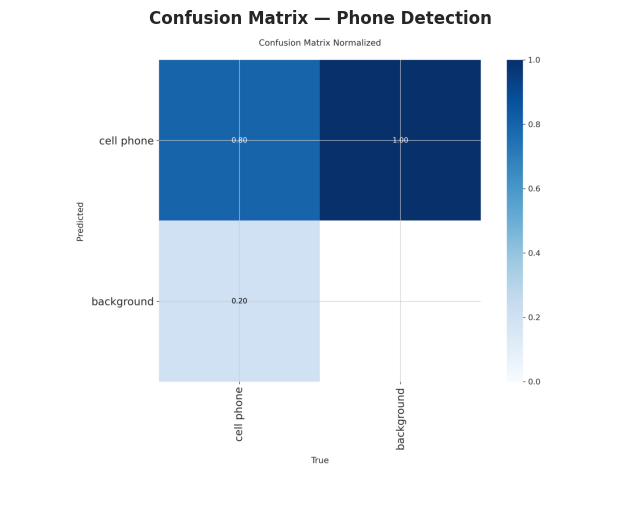

In [ ]:

confusion_matrix_path = os.path.join(RUN_DIR, "confusion_matrix_normalized.png")
if not os.path.exists(confusion_matrix_path):
    confusion_matrix_path = os.path.join(RUN_DIR, "confusion_matrix.png")

if os.path.exists(confusion_matrix_path):
    img = Image.open(confusion_matrix_path)
    plt.figure(figsize=(8, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix — Phone Detection", fontweight="bold")
    plt.show()
else:
    print("⚠️ Confusion matrix image not found. It is generated automatically by "
          "model.val() with plots=True — re-run the evaluation cell above if needed.")



## 16. Prediction on Images

Upload an image and run inference with the trained model. We display the **original**
and **predicted** (annotated) image side by side, along with the confidence score of
each detection.


📤 Please select an image to upload...


Saving 60_jpg.rf.MulIw9HhC1UynhvdfR2o.jpg to 60_jpg.rf.MulIw9HhC1UynhvdfR2o.jpg


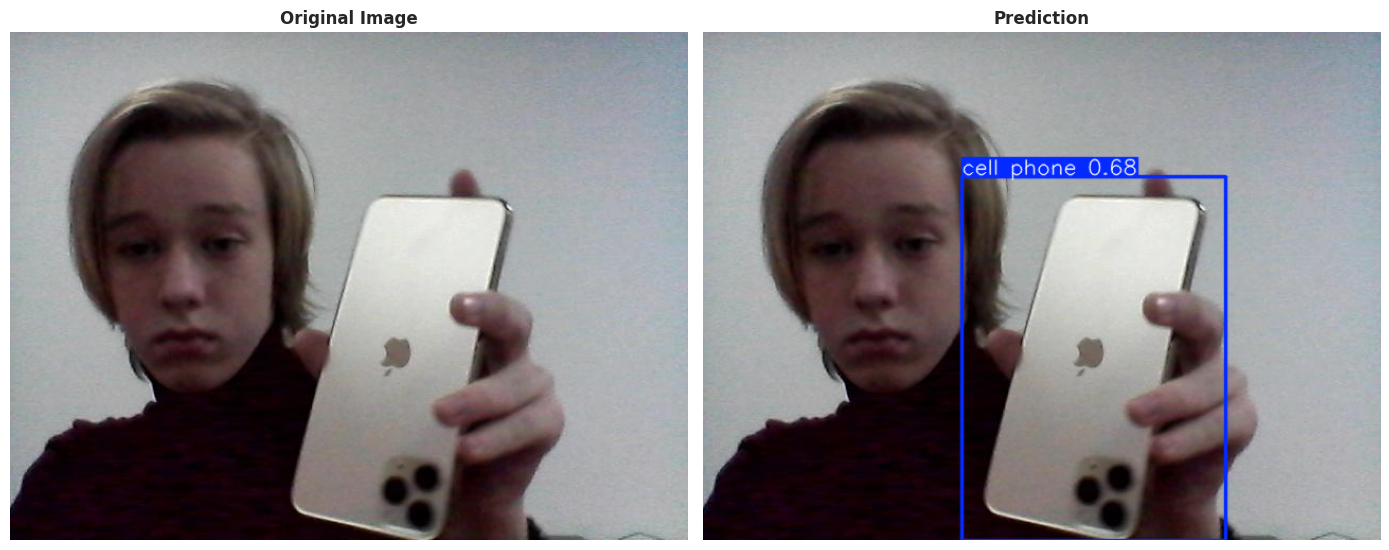

🔍 Detected 1 object(s):


NameError: name 'CLASS_NAMES' is not defined

In [ ]:

from google.colab import files

def predict_on_uploaded_image(model: YOLO, conf_threshold: float = 0.25):
    '''Prompt the user to upload an image, run inference, and display results.'''
    print(" Please select an image to upload...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        image_path = filename
        original = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

        pred_results = model.predict(image_path, conf=conf_threshold, verbose=False)
        pred_result = pred_results[0]
        predicted_image = cv2.cvtColor(pred_result.plot(), cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        axes[0].imshow(original)
        axes[0].set_title("Original Image", fontweight="bold")
        axes[0].axis("off")

        axes[1].imshow(predicted_image)
        axes[1].set_title("Prediction", fontweight="bold")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

        boxes = pred_result.boxes
        if boxes is not None and len(boxes) > 0:
            print(f"🔍 Detected {len(boxes)} object(s):")
            for i, (cls_id, conf) in enumerate(zip(boxes.cls.tolist(), boxes.conf.tolist())):
                class_name = CLASS_NAMES[int(cls_id)] if int(cls_id) < len(CLASS_NAMES) else str(int(cls_id))
                print(f"   {i+1}. {class_name}: {conf:.2%} confidence")
        else:
            print("🔍 No objects detected above the confidence threshold.")

        # Save annotated result to Drive
        out_path = os.path.join(OUTPUTS_DIR, f"prediction_{os.path.basename(image_path)}")
        cv2.imwrite(out_path, cv2.cvtColor(predicted_image, cv2.COLOR_RGB2BGR))
        print(f"💾 Saved annotated prediction to: {out_path}")


# Run this cell and use the upload dialog that appears
predict_on_uploaded_image(best_model, conf_threshold=0.25)


## Error Analysis

This section analyzes the model predictions to identify detection errors. The analysis focuses on false positive cases, where the model detects an object incorrectly, and false negative cases, where the model fails to detect the target object.

Comparing ground truth annotations with model predictions helps understand the model limitations and provides insights for future improvements.

In [ ]:

def compute_iou(box1, box2):
    '''Compute IoU between two boxes in (x1, y1, x2, y2) format.'''
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


def find_error_cases(model: YOLO, images_dir: str, labels_dir: str,
                      conf_threshold: float = 0.25, iou_threshold: float = 0.5,
                      max_samples: int = 150):
    '''Identify false-positive and false-negative examples on a validation subset.'''
    img_files = [f for f in os.listdir(images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    sample_files = random.sample(img_files, min(max_samples, len(img_files)))

    false_positive_cases = []
    false_negative_cases = []

    for img_file in tqdm(sample_files, desc="Analyzing errors"):
        img_path = os.path.join(images_dir, img_file)
        label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        gt_boxes = [yolo_to_xyxy((x, y, bw, bh), w, h)
                    for _, x, y, bw, bh in load_yolo_labels(label_path)]

        result = model.predict(img_path, conf=conf_threshold, verbose=False)[0]
        pred_boxes = result.boxes.xyxy.tolist() if result.boxes is not None else []

        matched_gt = set()
        matched_pred = set()
        for pi, pbox in enumerate(pred_boxes):
            best_iou, best_gi = 0, -1
            for gi, gbox in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                iou = compute_iou(pbox, gbox)
                if iou > best_iou:
                    best_iou, best_gi = iou, gi
            if best_iou >= iou_threshold:
                matched_gt.add(best_gi)
                matched_pred.add(pi)

        # Unmatched predictions => false positives
        if len(pred_boxes) > len(matched_pred):
            false_positive_cases.append(img_file)
        # Unmatched ground truth => false negatives (missed detections)
        if len(gt_boxes) > len(matched_gt):
            false_negative_cases.append(img_file)

    return false_positive_cases, false_negative_cases


val_labels_dir = dataset_stats.get("val", {}).get("labels_dir")
fp_cases, fn_cases = find_error_cases(best_model, val_images_dir, val_labels_dir)

print(f"⚠️  False Positive examples found : {len(fp_cases)}")
print(f"⚠️  False Negative examples found : {len(fn_cases)}")


In [ ]:

def plot_error_examples(images_dir: str, labels_dir: str, file_list: list,
                         title: str, model: YOLO, conf_threshold: float = 0.25,
                         num_examples: int = 4):
    '''Plot ground-truth vs. prediction side by side for a set of error examples.'''
    examples = file_list[:num_examples]
    if not examples:
        print(f"No examples found for: {title}")
        return

    fig, axes = plt.subplots(len(examples), 2, figsize=(10, 5 * len(examples)))
    if len(examples) == 1:
        axes = axes.reshape(1, -1)

    for row, img_file in enumerate(examples):
        img_path = os.path.join(images_dir, img_file)
        label_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        gt_img = img.copy()
        for cls_id, x, y, bw, bh in load_yolo_labels(label_path):
            x1, y1, x2, y2 = [int(v) for v in yolo_to_xyxy((x, y, bw, bh), w, h)]
            cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        result = model.predict(img_path, conf=conf_threshold, verbose=False)[0]
        pred_img = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

        axes[row, 0].imshow(gt_img)
        axes[row, 0].set_title(f"Ground Truth: {img_file}", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(pred_img)
        axes[row, 1].set_title("Prediction", fontsize=9)
        axes[row, 1].axis("off")

    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_error_examples(val_images_dir, val_labels_dir, fp_cases,
                     "False Positive Examples (Model over-detects)", best_model)
plot_error_examples(val_images_dir, val_labels_dir, fn_cases,
                     "False Negative Examples (Model misses phones)", best_model)



## 21.Model Export

After completing the training and evaluation process, the trained model is exported into different formats to support future deployment scenarios.

The exported formats include:

- **PyTorch (.pt):** Used for Python-based inference and further model development.
- **TorchScript:** A serialized format suitable for deployment in different environments.
- **ONNX:** A cross-platform format that can be used with various inference engines.

The exported models are saved for integration with the Driver Monitoring System.


In [ ]:

export_paths = {"pytorch": best_saved_path}

# --- TorchScript export ---
torchscript_path = best_model.export(format="torchscript", imgsz=640)
export_paths["torchscript"] = shutil.copy2(torchscript_path, FINAL_MODEL_DIR)

# --- ONNX export ---
onnx_path = best_model.export(format="onnx", imgsz=640, opset=12, simplify=True)
export_paths["onnx"] = shutil.copy2(onnx_path, FINAL_MODEL_DIR)

print("Model export complete. Files saved to Google Drive:")
for fmt, path in export_paths.items():
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"   {fmt:12s}: {path}  ({size_mb:.2f} MB)")



## 22. Performance Summary


This section creates a final summary table containing the main performance metrics of the trained model.

The summary includes detection accuracy metrics, inference speed, model size, and training information. The generated table can be used directly in the project report or presentation.

In [ ]:

model_size_mb = os.path.getsize(BEST_WEIGHTS_PATH) / (1024 * 1024)

summary_data = {
    "Metric": [
        "Precision", "Recall", "mAP50", "mAP50-95",
        "Inference FPS", "Inference Time (ms)",
        "Model Size (MB)", "Training Time (min)", "Total Training Epochs",
    ],
    "Value": [
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{map50:.4f}",
        f"{map50_95:.4f}",
        f"{fps:.2f}",
        f"{inference_ms:.2f}",
        f"{model_size_mb:.2f}",
        f"{train_duration_min:.2f}",
        f"{len(results_df)}",
    ],
}

summary_df = pd.DataFrame(summary_data)
summary_csv_path = os.path.join(REPORTS_DIR, "performance_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)

print("FINAL PERFORMANCE SUMMARY — DMS Phone Detection (YOLOv8m)")
print("=" * 55)
print(summary_df.to_string(index=False))
print("=" * 55)
print(f" Summary table saved to: {summary_csv_path}")

summary_df


## 23. Conclusion

This notebook presented the complete development pipeline for a driver phone usage detection model as a part of a Driver Monitoring System.

The workflow covered dataset preparation, annotation verification, YOLOv8 model training, performance evaluation, error analysis, and model export for deployment. The trained model was evaluated using different metrics to measure its detection performance and reliability.

The results demonstrate the ability of the YOLOv8 model to detect phone usage in driving scenarios, providing a foundation that can be integrated with other driver monitoring modules such as seatbelt detection and drowsiness analysis.

Future improvements can include expanding the dataset, adding more diverse driving conditions, and optimizing the model for real-time deployment on edge devices.